## Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from typing import Tuple, Optional


## Solution 1: Complete NoiseScheduler Class

In [2]:
class NoiseScheduler:
    """
    Fixed variance schedule for forward diffusion process.
    """

    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02):
        """
        Initialize noise scheduler with linear beta schedule.
        """
        self.num_timesteps = num_timesteps

        # Create linear beta schedule
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)

        # Compute alphas and cumulative products
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.ones(1), self.alphas_cumprod[:-1]])

        # Pre-compute useful quantities
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def get_coefficients(self, timestep):
        """
        Get forward diffusion coefficients for timestep(s).
        """
        device = timestep.device
        sqrt_alphas_cumprod = self.sqrt_alphas_cumprod.to(device)[timestep]
        sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod.to(device)[
            timestep
        ]

        # Reshape to (batch, 1, 1, 1) for broadcasting with images
        sqrt_alphas_cumprod = sqrt_alphas_cumprod.reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.reshape(
            -1, 1, 1, 1
        )

        return sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod


## Solution 2: Forward Diffusion Process

In [3]:
def add_noise(x_0, timestep, scheduler, noise=None):
    """
    Forward diffusion: Add noise to image at timestep t.

    Formula: x_t = sqrt(ᾱ_t) * x_0 + sqrt(1 - ᾱ_t) * ε
    """
    # Sample random noise if not provided
    if noise is None:
        noise = torch.randn_like(x_0)

    # Get coefficients from scheduler
    sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod = scheduler.get_coefficients(
        timestep
    )

    # Apply forward diffusion formula
    x_t = sqrt_alphas_cumprod * x_0 + sqrt_one_minus_alphas_cumprod * noise

    return x_t, noise


## Solution 3: TimeEmbedding Class

In [4]:
class TimeEmbedding(nn.Module):
    """
    Sinusoidal time embedding for timestep conditioning.
    """

    def __init__(self, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, timestep):
        """
        Convert timestep to embedding using sinusoidal functions.
        """
        device = timestep.device
        half_dim = self.embedding_dim // 2

        # Create frequency schedule
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device) / half_dim
        )

        # Multiply timestep by frequencies
        args = timestep[:, None].float() * freqs[None, :]

        # Apply sine and cosine and concatenate
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        return embedding


## Solution 4: ResidualBlock with Time Conditioning

In [5]:
class ResidualBlock(nn.Module):
    """
    Residual block with timestep conditioning using FiLM (Feature-wise Linear Modulation).
    """

    def __init__(self, in_channels, out_channels, time_embedding_dim=128):
        super().__init__()

        self.norm1 = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(num_groups=32, num_channels=out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # Time conditioning MLP (FiLM)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embedding_dim, out_channels),
            nn.SiLU(),
            nn.Linear(out_channels, out_channels),
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, time_embedding):
        """
        Forward pass with time conditioning via FiLM.
        """
        # First path with time conditioning
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # Apply time conditioning via FiLM (modulate by time)
        time_scale_shift = self.time_mlp(time_embedding)[:, :, None, None]
        h = h * time_scale_shift

        # Second path
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        # Add skip connection
        return h + self.skip(x)


## Solution 5: SimpleUNet Architecture

In [10]:
class SimpleUNet(nn.Module):
    """
    Simple U-Net for MNIST noise prediction.
    """

    def __init__(self, image_channels=1, base_channels=64, time_embedding_dim=128):
        super().__init__()

        self.time_embedding = TimeEmbedding(time_embedding_dim)

        # Initial conv
        self.init_conv = nn.Conv2d(
            image_channels, base_channels, kernel_size=3, padding=1
        )

        # Encoder (downsampling)
        self.down_conv1 = nn.Conv2d(
            base_channels, base_channels, kernel_size=4, stride=2, padding=1
        )
        self.down_res1 = ResidualBlock(
            base_channels, base_channels * 2, time_embedding_dim
        )

        self.down_conv2 = nn.Conv2d(
            base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1
        )
        self.down_res2 = ResidualBlock(
            base_channels * 2, base_channels * 2, time_embedding_dim
        )

        # Middle (bottleneck)
        self.middle_res = ResidualBlock(
            base_channels * 2, base_channels * 2, time_embedding_dim
        )

        # Decoder (upsampling)
        self.up_conv2 = nn.ConvTranspose2d(
            base_channels * 2, base_channels * 2, kernel_size=4, stride=2, padding=1
        )
        self.up_res2 = ResidualBlock(
            base_channels * 2, base_channels, time_embedding_dim
        )

        self.up_conv1 = nn.ConvTranspose2d(
            base_channels, base_channels, kernel_size=4, stride=2, padding=1
        )
        self.up_res1 = ResidualBlock(base_channels, base_channels, time_embedding_dim)

        # Final output
        self.final_norm = nn.GroupNorm(num_groups=32, num_channels=base_channels)
        self.final_conv = nn.Conv2d(
            base_channels, image_channels, kernel_size=3, padding=1
        )

    def forward(self, x, timestep):
        """
        Predict noise given noisy image and timestep.
        """
        # Create time embedding
        time_emb = self.time_embedding(timestep)

        # Initial conv
        h = self.init_conv(x)

        # Encoder (downsampling: 28x28 → 14x14 → 7x7)
       
        h = self.down_conv1(h)  # (batch, 64, 14, 14) - downsample first
        h = self.down_res1(h, time_emb)  # (batch, 128, 14, 14) - then residual

        h = self.down_conv2(h)  # (batch, 128, 7, 7) - downsample
        h = self.down_res2(h, time_emb)  # (batch, 128, 7, 7) - then residual

        # Middle
        h = self.middle_res(h, time_emb)  # (batch, 128, 7, 7)

        # Decoder
        h = self.up_conv2(h)  # (batch, 128, 14, 14)
        h = self.up_res2(h, time_emb)  # (batch, 64, 14, 14)

        h = self.up_conv1(h)  # (batch, 64, 28, 28)
        h = self.up_res1(h, time_emb)  # (batch, 64, 28, 28)

        # Final output
        h = self.final_norm(h)
        h = F.silu(h)
        h = self.final_conv(h)  # (batch, 1, 28, 28)

        return h


## Solution 6: Training Step with MSE Loss

In [7]:
def train_step(model, optimizer, x_0, scheduler, device):
    """
    Single training step with MSE loss.

    Core of diffusion model training:
    - Sample random timesteps
    - Apply forward diffusion to create noisy images
    - Train model to predict the noise
    - Use MSE loss (not adversarial)
    """
    model.train()
    x_0 = x_0.to(device)
    batch_size = x_0.shape[0]

    # Sample random timesteps (0 to num_timesteps-1)
    timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device)

    # Sample random noise
    noise = torch.randn_like(x_0)

    # Apply forward diffusion
    x_t, _ = add_noise(x_0, timesteps, scheduler, noise)

    # Predict noise with model
    predicted_noise = model(x_t, timesteps)

    # Compute MSE loss (main advantage over cGAN!)
    loss = F.mse_loss(predicted_noise, noise)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return loss.item()


## Solution 7: Training Loop Setup

In [8]:
# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load MNIST
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"\nDataset loaded: {len(train_dataset)} images")
print(f"Batches per epoch: {len(train_loader)}")


Using device: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 9.73MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw


Dataset loaded: 60000 images
Batches per epoch: 1875


## Solution 8: Create and Train Model

In [11]:
# Create model and scheduler
model = SimpleUNet(image_channels=1, base_channels=64, time_embedding_dim=128)
model = model.to(device)

scheduler = NoiseScheduler(num_timesteps=1000, beta_start=0.0001, beta_end=0.02)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("\nModel created:")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device: {device}")
print(f"\nTraining for 10 epochs...\n")

# Training loop (shortened for demonstration)
num_epochs = 10
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    num_batches = 0

    for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        loss = train_step(model, optimizer, images, scheduler, device)
        epoch_loss += loss
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

print("\n✓ Training complete!")



Model created:
  Parameters: 1,795,969
  Device: cuda

Training for 10 epochs...



Epoch 1/10: 100%|██████████| 1875/1875 [00:47<00:00, 39.54it/s]


Epoch 1: Loss = 0.1170


Epoch 2/10: 100%|██████████| 1875/1875 [00:47<00:00, 39.58it/s]


Epoch 2: Loss = 0.0412


...

Epoch 8: Loss = 0.0298


Epoch 9/10: 100%|██████████| 1875/1875 [00:47<00:00, 39.83it/s]


Epoch 9: Loss = 0.0292


Epoch 10/10: 100%|██████████| 1875/1875 [00:47<00:00, 39.24it/s]

Epoch 10: Loss = 0.0286

✓ Training complete!


## Visualize Training Losses

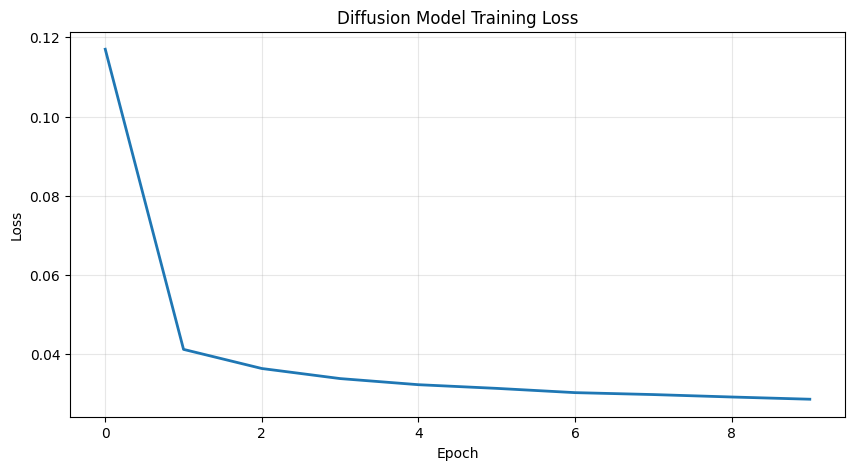


Loss Summary:
  Initial: 0.1170
  Final: 0.0286
  Improvement: 75.5%


In [12]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Diffusion Model Training Loss")
plt.grid(alpha=0.3)
plt.show()

print(f"\nLoss Summary:")
print(f"  Initial: {losses[0]:.4f}")
print(f"  Final: {losses[-1]:.4f}")
print(f"  Improvement: {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%")
